In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import norm

np.random.seed(0)
I = 5
tau = 0.2783047
full_df = pd.read_csv('case_by_case_output.csv')
full_df['parallax'] = np.log(full_df['parallax'])
full_df['absorption'] = np.log(full_df['absorption'])
full_df['mass'] = np.log(full_df['mass'])

ids = full_df['ID'].unique()
cols = ['logAge', 'FeH', 'parallax', 'absorption', 'mass']

filtered_df = pd.DataFrame()
for i in ids:
    group = full_df[full_df["ID"] == i].copy()
    q = group["absorption"].quantile(0.007)
    group_filtered = group[group["absorption"] >= q]

    filtered_df = pd.concat([filtered_df, group_filtered], ignore_index=True)

full_df_original = full_df
full_df = filtered_df

def CBC_sample_generator(num_samples=1, source_data=None):
    samples = source_data.sample(n=num_samples, replace=True).values
    return pd.DataFrame(samples, columns = cols)

## Two-Stage Fully Bayesian Algorithm

In [2]:
np.random.seed(0)
T = 30000 # Total number of iterations
n = 30 # Number of stars/groups
gamma_prior_mean = 9
gamma_prior_var   = 0.5**2
gamma_var = (gamma_prior_var * tau**2) / (tau**2 + gamma_prior_var*I)
gamma_sd = np.sqrt(gamma_var)
# -------------------------------------------------------------------
# 1) Generating CBC Samples
# -------------------------------------------------------------------
cbc = {}

for id in ids:
    block = full_df.loc[full_df['ID'] == id]
    samples = CBC_sample_generator(num_samples=T,source_data=block[cols]).reset_index(drop=True)
    cbc[id] = samples

# -------------------------------------------------------------------
# 2)  Initialization (t = 0):
# -------------------------------------------------------------------
logAge = np.zeros((n, T), dtype=float)
THETA = np.zeros((n, T, 4), dtype=float)
gamma_ts = np.zeros(T, dtype=float)

for i, id in enumerate(ids):
    row0 = cbc[id].iloc[0].values
    logAge[i, 0] = row0[0]
    THETA[i, 0, :] = row0[1:5]

# -------------------------------------------------------------------
# 4) Iterations t = 1..T
# -------------------------------------------------------------------
tiny = 1e-300  # for safe division

for t in range(1, T):
    #  gamma_t ~ N(mean(logAge[:, t-1]), tau / sqrt(I))
    gamma_mean = (gamma_prior_mean * tau**2 + gamma_prior_var * np.sum(THETA[:, t-1, 0])) / (tau**2 + gamma_prior_var*I)
    gamma_t = np.random.normal(loc=gamma_mean, scale=gamma_sd)
    gamma_ts[t] = gamma_t

    # Propose from the t-th row of each ID's cbc
    for i, id in enumerate(ids):
        logAge_curr = logAge[i, t-1]
        # Proposed state from cbc row t
        prop_row = cbc[id].iloc[t].values
        logAge_prop = prop_row[0]
        theta_prop = prop_row[1:5]

        # MH ratio
        num = norm.pdf(logAge_prop, loc=gamma_t, scale=tau)
        den = norm.pdf(logAge_curr, loc=gamma_t, scale=tau)
        alpha = min(1.0, (num + tiny) / (den + tiny))

        if np.random.rand() < alpha:
            # accept
            logAge[i, t] = logAge_prop
            THETA[i, t, :] = theta_prop
        else:
            # reject
            logAge[i, t] = logAge_curr
            THETA[i, t, :] = THETA[i, t-1, :]

records = []
for t in range(T):
    for i, id in enumerate(ids):
        row = [logAge[i, t], *THETA[i, t, :], id]
        records.append(row)

results = pd.DataFrame(
    records,
    columns=['logAge','FeH','parallax','absorption','mass','ID']
)
results.to_csv('TSFB.csv')

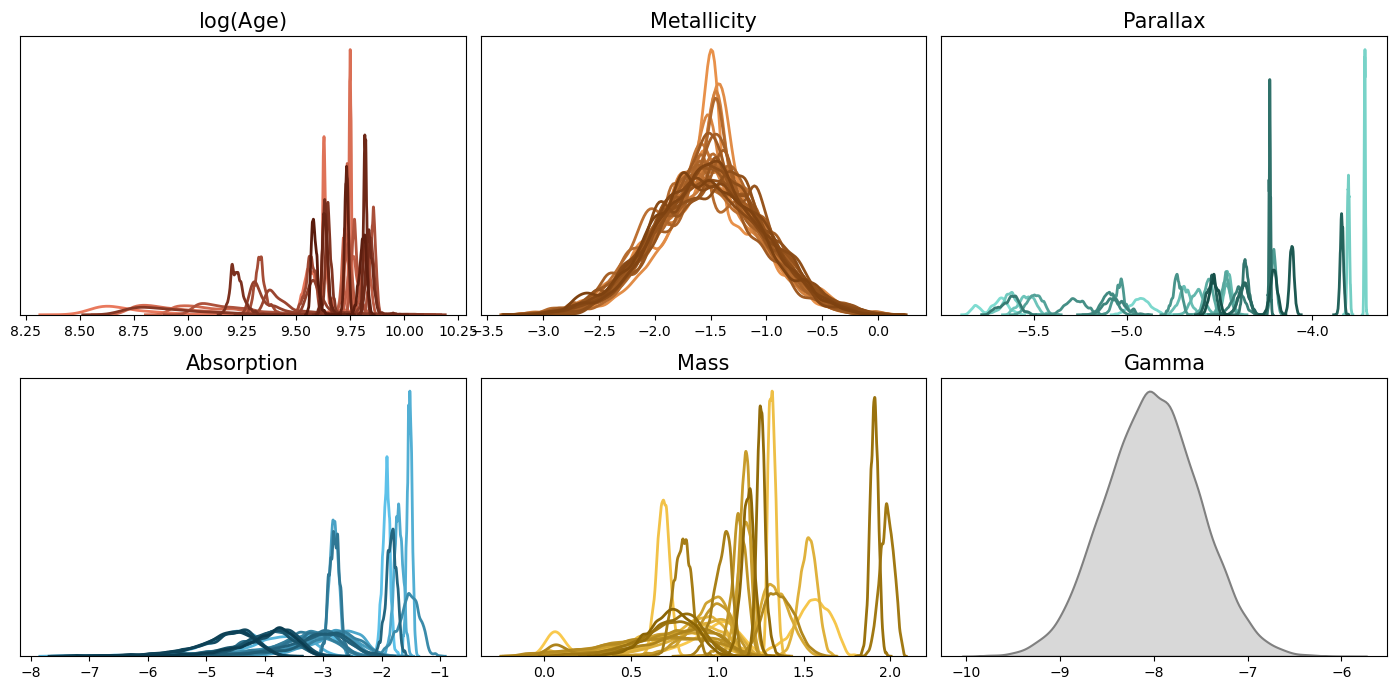

In [4]:
TSFB = results
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

selected_ids = ids

color_bounds = {
    "logAge": ("#E9795D", "#5A1B0C"),
    "FeH": ("#E8914A", "#7E4210"),
    "parallax": ("#7FDCD1", "#165049"),
    "absorption": ("#5DC1E9", "#0B3D51"),
    "mass": ("#F9C94D", "#8B6404"),
}

def make_colors(light_hex, dark_hex, n):
    cmap = LinearSegmentedColormap.from_list("grad", [light_hex, dark_hex])
    return [cmap(i/(n-1)) for i in range(n)] if n > 1 else [dark_hex]
subplot_titles = {
        "logAge": r"$\log(\mathrm{Age})$",
        "FeH": "Metallicity",
        "parallax": r"Parallax",
        "absorption": r"Absorption",
        "mass": r"Mass",
        "gamma": "Gamma"
}

for i, var in enumerate(cols):
    ax = axes[i]
    light, dark = color_bounds[var]
    colors = make_colors(light, dark, len(selected_ids))

    for j, ID in enumerate(selected_ids):
        data = TSFB.loc[TSFB["ID"] == ID, var]
        sns.kdeplot(data, ax=ax, color=colors[j], lw=2, fill=False)
    ax.set_title(subplot_titles[var], fontsize=15)
    ax.set_ylabel("")
    ax.set_yticklabels([])
    ax.set_xlabel("")
    ax.tick_params(axis='y', length=0)
ax = axes[-1]
sns.kdeplot(gamma_ts[2000:], ax=ax, color="gray", fill=True, alpha=0.3, lw=1.5)

ax.set_title(subplot_titles["gamma"], fontsize=15)
ax.set_ylabel("")
ax.set_yticklabels([])
ax.set_xlabel("")
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig('TSFB_RealData_1.png')
plt.show()